# Clasisfiaction Metrics Demo  
- Understand Accuracy, Precision, Recal and F1
- Compare a 95/5 and an 85/15 clasification problem

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

np.random.seed(42)

## Scenario 1: Highly imbalanced dataset (95/5)

In [2]:
X, y = make_classification(
    n_samples=1000,
    n_features=6,
    n_informative=4,
    n_redundant=0,
    weights=[0.95, 0.05],
    random_state=42
)

pd.Series(y).value_counts()


0    944
1     56
Name: count, dtype: int64

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

pred = model.predict(X_test)

In [7]:
acuracy  = accuracy_score(y_test, pred)
print(acuracy)

0.945


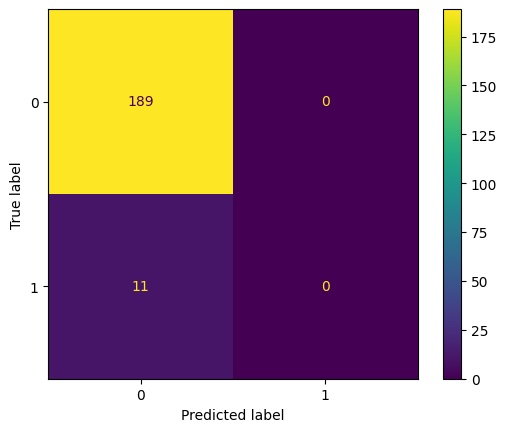

In [8]:
cm = confusion_matrix(y_test, pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.show()

precision = TP / (TP + FP)  

recall = TP / (TP + FN)  

f1 = 2 * (precision * recall) / (precision + recall)

In [9]:
precision = precision_score(y_test, pred, zero_division=0)
recal = recall_score(y_test, pred, zero_division=0)
f1 = f1_score(y_test, pred, zero_division=0)

pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recal", "F1"],
    "Value": [acuracy, precision, recal, f1]
})

,Metric,Value
0,Accuracy,0.945
1,Precision,0.000
2,Recal,0.000
3,F1,0.000


## Scenario 2: Less imbalanced dataset (95/5)

In [10]:
X, y = make_classification(
    n_samples=1000,
    n_features=6,
    n_informative=4,
    n_redundant=0,
    weights=[0.85, 0.15],
    random_state=42
)

pd.Series(y).value_counts()

0    845
1    155
Name: count, dtype: int64

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

pred = model.predict(X_test)

In [12]:
acuracy  = accuracy_score(y_test, pred)
print(acuracy)

0.855


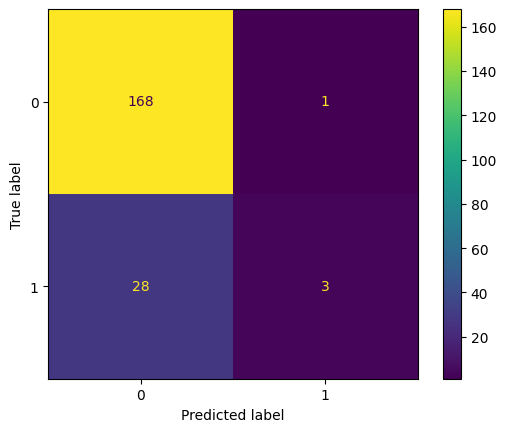

In [13]:
cm = confusion_matrix(y_test, pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.show()

# Key Takeaways

## Accuracy

Good for balanced datasets.

## Precision

When false positives are expensive.

## Recall

When false negatives are expensive.

## F1

When both Precision and Recall matter.

### Important lesson

Always inspect the confusion matrix and never rely only on Accuracy when classes are imbalanced.

In [14]:
precision = precision_score(y_test, pred, zero_division=0)
recal = recall_score(y_test, pred, zero_division=0)
f1 = f1_score(y_test, pred, zero_division=0)

pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recal", "F1"],
    "Value": [acuracy, precision, recal, f1]
})

,Metric,Value
0,Accuracy,0.855000
1,Precision,0.750000
2,Recal,0.096774
3,F1,0.171429
